In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time 

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [38]:
inicio = time.perf_counter()

In [39]:
# Reprodutibilidade
SEED = 123

In [40]:
df = pd.read_csv("final_dataset.csv")

In [41]:
# Agrupa chuva intensa na classe Rain
df["precipitation"] = df["precipitation"].replace("Extreme rain", "Rain")

X = df.drop(columns=["precipitation"])
y = df["precipitation"]

labels = ["Rain", "No rain"]

y.value_counts()

precipitation
No rain    431380
Rain        37431
Name: count, dtype: int64

In [42]:
def criar_modelo_nb(seed=SEED):
    """Cria o pipeline do modelo.

    O undersampling fica dentro da validação cruzada, evitando balancear
    antes da separação treino/teste de cada fold.
    """
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("modelo", MultinomialNB())
    ])

def criar_modelo_logistico_elastic_net(seed=SEED, C=1.0, l1_ratio=0.5):
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("modelo", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=l1_ratio,
            C=C,
            max_iter=10000,
            random_state=seed,
            n_jobs=-1
        ))
    ])


def metricas_da_matriz(cm):
    """Calcula métricas considerando a ordem: labels = ['Rain', 'No rain']."""
    VP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    VN = cm[1, 1]

    acuracia = (VP + VN) / cm.sum()
    sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    especificidade = VN / (VN + FP) if (VN + FP) > 0 else np.nan

    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade
    }

In [43]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cm_total = np.zeros((2, 2), dtype=int)
matrizes_folds = {}
resultados = []

y_test_total = []
y_prob_total = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    modelo_logistico = criar_modelo_logistico_elastic_net(C=1.0, l1_ratio=0.5)
    modelo_logistico.fit(X_train_fold, y_train_fold)

    y_pred_fold = modelo_logistico.predict(X_test_fold)

    cm_fold = confusion_matrix(
        y_test_fold,
        y_pred_fold,
        labels=labels
    )

    cm_total += cm_fold
    matrizes_folds[f"Fold {fold}"] = cm_fold

    # Probabilidade prevista para a classe Rain
    indice_rain = list(modelo_logistico.named_steps["modelo"].classes_).index("Rain")
    y_prob_fold = modelo_logistico.predict_proba(X_test_fold)[:, indice_rain]

    y_test_bin_fold = (y_test_fold == "Rain").astype(int)

    metricas = metricas_da_matriz(cm_fold)
    metricas["AUC"] = roc_auc_score(y_test_bin_fold, y_prob_fold)

    for metrica, valor in metricas.items():
        resultados.append({
            "Fold": fold,
            "Métrica": metrica,
            "Valor": valor
        })

    y_test_total.extend(y_test_bin_fold.to_numpy())
    y_prob_total.extend(y_prob_fold)

In [44]:
matriz_confusao_total = pd.DataFrame(
    cm_total,
    index=["Real Rain", "Real No rain"],
    columns=["Predito Rain", "Predito No rain"]
)

resultados_cv = pd.DataFrame(resultados)

tabela_cv = resultados_cv.pivot(
    index="Métrica",
    columns="Fold",
    values="Valor"
)

tabela_cv.columns = [f"Fold {col}" for col in tabela_cv.columns]
tabela_cv["Média"] = tabela_cv.mean(axis=1)
tabela_cv["DP"] = tabela_cv.std(axis=1)

display(matriz_confusao_total)
display(tabela_cv)

,Predito Rain,Predito No rain
Real Rain,28475,8956
Real No rain,142043,289337


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,DP
Métrica,,,,,,,
AUC,0.788985,0.789216,0.789391,0.788099,0.790389,0.789216,0.000736
Acurácia,0.678818,0.679849,0.676831,0.677385,0.676671,0.677911,0.001230
Especificidade,0.671786,0.672864,0.669445,0.669943,0.669584,0.670724,0.001360
Sensibilidade,0.759850,0.760353,0.761956,0.763158,0.758349,0.760733,0.001672


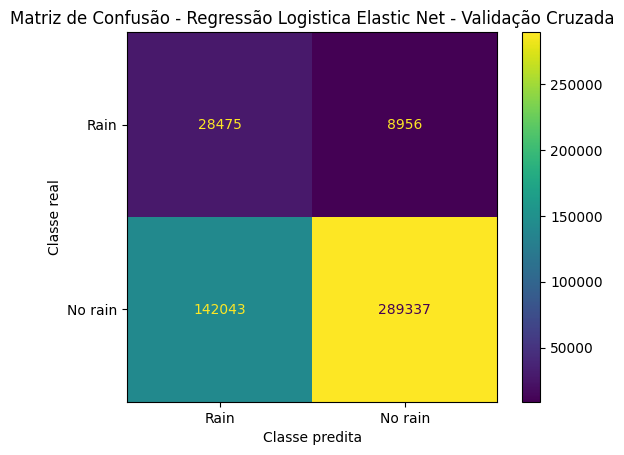

In [45]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_total.astype(int),
    display_labels=labels
).plot(values_format='d')

plt.title("Matriz de Confusão - Regressão Logistica Elastic Net - Validação Cruzada")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")

plt.savefig("matriz_confusao_regressao_logistica_elasticnet.png", dpi=300, bbox_inches="tight")

plt.show()

AUC geral: 0.7892023626778943


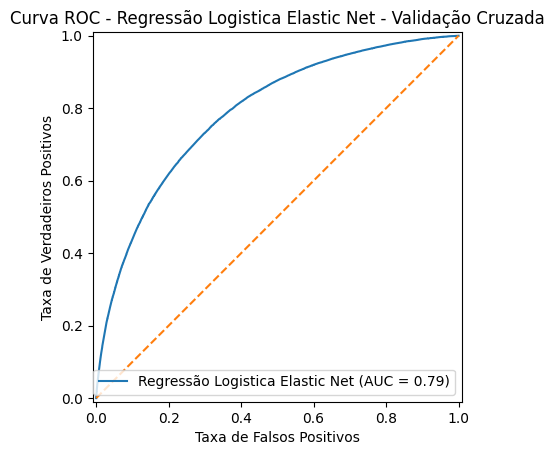

In [46]:
y_test_total = np.array(y_test_total)
y_prob_total = np.array(y_prob_total)

fpr, tpr, thresholds = roc_curve(y_test_total, y_prob_total)
auc = roc_auc_score(y_test_total, y_prob_total)

print("AUC geral:", auc)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc,
    estimator_name="Regressão Logistica Elastic Net"
).plot()

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Regressão Logistica Elastic Net - Validação Cruzada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")

plt.savefig("curva_roc_reg_logistica_elasticnet.png", dpi=300, bbox_inches="tight")

plt.show()

In [47]:
fim = time.perf_counter()

tempo_total = fim - inicio

horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

print(f"Tempo total do experimento: {horas}h {minutos}min {segundos:.2f}s")

Tempo total do experimento: 0h 0min 27.29s
